# Bank Customer Churn Prediction

# 1. Understanding the Problem
The goal of this project is to perform **Exploratory Data Analysis(EDA)** on the bank customer dataset and prepare a clean final dataset that can be used for building a machine learning model to predict **customer churn**.

We need to:
- Understand the data structure
- Handle missing values
- Explore relationships between features and the target
- Perform feature selection
- Deliver a clean dataset ready for building a model

# 2. Load and Inspect the Dataset
This step involves loading the dataset and inspecting its structure, completeness, and main characteristics.

### Loading the required libraries for the Data Analysis of the Dataset

In [323]:
# Data Manipulation and Analysis
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Feauture Selection
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.impute import KNNImputer

In [324]:
# Load the dataset (Make sure the CSV is in the same folder)
file_path = "bank_customer_analytics.csv"
df = pd.read_csv(file_path)

# Inspection of the First 5 Rows of the Dataset
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns\n")
df.head()

Dataset contains 3000 rows and 12 columns



,CustomerID,Age,Gender,MaritalStatus,Income,Savings,CreditScore,LoanAmount,LoanStatus,AccountType,YearsWithBank,Churn
0,C0001,25.0,FEMALE,single,80000.0,15000.0,600.0,50000.0,approved,joint,NaN,no
1,C0002,35.0,male,single,40000.0,5000.0,700.0,40000.0,approved,joint,10.0,no
2,C0003,35.0,female,single,100000.0,20000.0,800.0,50000.0,defaulted,checking,10.0,no
3,C0004,45.0,male,married,80000.0,20000.0,750.0,30000.0,approved,checking,NaN,no
4,C0005,45.0,male,married,40000.0,25000.0,750.0,20000.0,rejected,checking,2.0,yes


In [325]:
# Columns Overview
print("Columns in the dataset:")
df.columns

Columns in the dataset:


Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'Income', 'Savings',
       'CreditScore', 'LoanAmount', 'LoanStatus', 'AccountType',
       'YearsWithBank', 'Churn'],
      dtype='object')

### Insights of the First 5 Rows and the columns of the Dataset.

The dataset combines:
- demographic (Age, Gender, MaritalStatus),
- financial (Income, Savings, CreditScore, LoanAmount),
- account information (LoanStatus, AccountType, YearsWithBank),
- and the target variable outcome (Churn), which shows whether the customer left the bank.

There are clear opportunities for data cleaning, especially:
- fixing inconsistent capitalization (e.g., FEMALE, female),
- Missing values in the dataset (e.g., YearsWithBank),

In [326]:
# Statistical summary for numerical features
df.describe()

,Age,Income,Savings,CreditScore,LoanAmount,YearsWithBank
count,2838.000000,2865.000000,2854.000000,2857.000000,2867.000000,2713.000000
mean,39.048626,68293.193717,21483.882270,694.662233,34080.920823,6.883155
std,9.816456,19997.850070,20893.054327,68.907793,9972.978607,5.907284
min,25.000000,40000.000000,5000.000000,600.000000,20000.000000,1.000000
25%,35.000000,60000.000000,10000.000000,650.000000,30000.000000,2.000000
50%,35.000000,60000.000000,15000.000000,700.000000,30000.000000,5.000000
75%,45.000000,80000.000000,20000.000000,750.000000,40000.000000,10.000000
max,55.000000,100000.000000,200000.000000,800.000000,50000.000000,100.000000


### Insights from the summary statistics (numeric columns)
- "Age" ranges from 25 to 55; the average age(mean) is 39 years old, and the median (50%) is 35, meaning the customer base is generally young to middle-aged and with no extreme outliers.
- "Income" ranges from 40,000 to 100,000 and standard variation (std) is ~20,000, which indicates variability among customers; average income (mean) is 68,293, but the median is 60,000 — since mean > median, the distribution is slightly right-skewed, meaning a small group of customers with significantly higher incomes pulls the mean upward.
- "Savings" range between 5,000 to 200,000 and show high variability (std = 20,893); average income(mean) is 21,483, but the median is 15,000, which shows a strong skew to customers with very high savings indicating possible outliers.
- "CreditScore" ranges from 600 to 800; mean(694) and median(700) are close, indicating a balanced credit distribution, with no extreme outliers.
- "LoanAmount" ranges from 20,000 to 50,000 with a median of 30,000, showing symmetrical distribution with no outliers.
- "YearsWithBank" shows that customers have been with the bank for a median of 5 years and a mean of 6.88 years; the range is 1 to 100 years, with an extreme unrealistic value of 100 years, which requires further investigation.

Sum up:
- Age distribution is mild and balanced with no problematic extremes.
- Income and Savings show significant variability and skewness, requiring possible imputation.
- CreditScore and LoanAmount are symmetric and have no outliers.
- YearsWithBank includes extreme outliers, which may affect the model performance negatively, so they should be investigated.

In [327]:
# Summary information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     3000 non-null   object 
 1   Age            2838 non-null   float64
 2   Gender         3000 non-null   object 
 3   MaritalStatus  3000 non-null   object 
 4   Income         2865 non-null   float64
 5   Savings        2854 non-null   float64
 6   CreditScore    2857 non-null   float64
 7   LoanAmount     2867 non-null   float64
 8   LoanStatus     3000 non-null   object 
 9   AccountType    3000 non-null   object 
 10  YearsWithBank  2713 non-null   float64
 11  Churn          3000 non-null   object 
dtypes: float64(6), object(6)
memory usage: 281.4+ KB


In [328]:
# Type of values in the DataFrame
df.dtypes.value_counts()

object     6
float64    6
Name: count, dtype: int64

### Insights of the Dataset Information
- The dataset contains 3000 rows and 12 columns, which shows a reasonably large dataset, suitable for reliable statistical analysis.
- We have two types of data: numerical (float64) in 6 columns and categorical (object) in 6 columns.
- Missing data is present only in numerical columns (Age, Income, Savings, CreditScore, LoanAmount, YearsWithBank).
- All categorical columns have no missing values.

In [329]:
# Sum of Missing Values per Column
df.isna().sum()

CustomerID         0
Age              162
Gender             0
MaritalStatus      0
Income           135
Savings          146
CreditScore      143
LoanAmount       133
LoanStatus         0
AccountType        0
YearsWithBank    287
Churn              0
dtype: int64

In [330]:
# Finding missing value percentages
missing = df.isna().sum()
missing_summary = pd.DataFrame({'Missing': missing, 'Percentage (%)': (missing/df.shape[0]*100).round(2)})
missing_summary = missing_summary[missing_summary['Missing'] > 0]

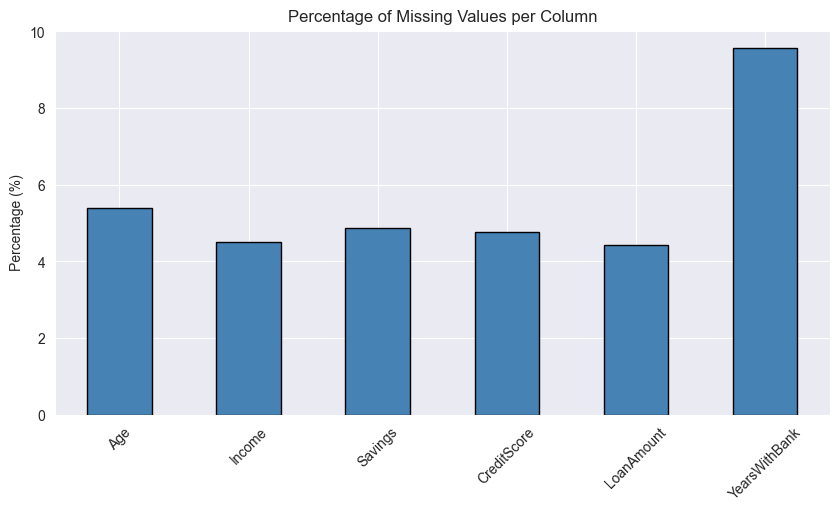

In [331]:
# Bar plot for missing value percentages
plt.figure(figsize=(10, 5))
missing_summary["Percentage (%)"].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Percentage of Missing Values per Column")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.show()

### Insights from the Missing Values Per Column
- Missing data appears only in numerical columns, confirming earlier findings from the Dataset Info.
- YearsWithBank has the highest number of missing values (287), making it the column we must handle first.
- Age, Income, Savings, CreditScore, LoanAmount have moderate missing data (133 to 162 rows).
- All categorical columns have no missing values, confirming earlier findings.

### Recommended way of Handling Missing Values
- K-Nearest Neighbors (KNN) Imputation: To ensure production-grade data quality, a model-based KNN Imputer is recommended to be deployed. For every missing value, the algorithm identifies the $k$ most similar customer profiles (neighbors) based on Euclidean distance across all available numerical features and imputes the missing value using their weighted average. This effectively preserves the multi-dimensional relationships within our banking data

# 3. Handle Missing Values
After inspecting the dataset, we need to identify and address missing values.

In [332]:
# Drop of Columns
# Here we will remove the irrelevant columns that have no value to our model. In our project that is the CustomerID.
df.drop(columns=['CustomerID'], inplace=True)

In [333]:
# Clean the column Gender to have two clean consistent values: male and female
df['Gender'] = df['Gender'].str.lower()
df['Gender'].value_counts()

Gender
female    1521
male      1479
Name: count, dtype: int64

In [334]:
# Percentage of Missing Values
missing = df.isna().sum()
missing_percentage = (missing / len(df) * 100).round(2)

missing_values = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percentage
})

print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("Missing values and their percentage in each column:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(missing_values)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Missing values and their percentage in each column:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
               Missing Count  Missing %
Age                      162       5.40
Gender                     0       0.00
MaritalStatus              0       0.00
Income                   135       4.50
Savings                  146       4.87
CreditScore              143       4.77
LoanAmount               133       4.43
LoanStatus                 0       0.00
AccountType                0       0.00
YearsWithBank            287       9.57
Churn                      0       0.00


### Insights from the Missing Values Per Column
- The percentage of missing values in each column confirms our insights from our first inspection of the DataSet in the previous step.
- YearsWithBank has the highest number of missing values.
- All the values are under 10%, which allows imputation.

### Advanced Imputation Strategy
- Since the missingness in all variables is well below the 10% threshold (maximum is 9.57% in `YearsWithBank`), dropping rows or columns would result in an unnecessary loss of valuable information.
- Standard statistical imputation (Mean/Median) treats each column in isolation. This distorts the original data distributions, artificially reduces variance, and completely ignores correlations between features (e.g., the logical relationship between `Age`, `Income`, and `Savings`).
- To ensure production-grade data quality, a model-based KNN Imputer will be deployed. For every missing value, the algorithm identifies the $k$ most similar customer profiles (neighbors) based on Euclidean distance across all available numerical features and imputes the missing value using their weighted average. This effectively preserves the multi-dimensional relationships within our banking dataset.

| Feature       | Missing % | Data Type   | Applied Strategy |
|---------------|-----------|-------------|------------------|
| Age           | 5.40 %    | Numerical   | KNN Imputer      |
| Income        | 4.50 %    | Numerical   | KNN Imputer      |
| Savings       | 4.87 %    | Numerical   | KNN Imputer      |
| CreditScore   | 4.77 %    | Numerical   | KNN Imputer      |
| LoanAmount    | 4.43 %    | Numerical   | KNN Imputer      |
| YearsWithBank | 9.57 %    | Numerical   | KNN Imputer      |

In [335]:
# Set the Imputation
def handle_missing_data_knn(data_frame, n_neighbors=5):
    """
    Performs advanced model-based missing value imputation using KNN.
    Encapsulated in a function to ensure clean, reusable, and production-ready code.
    """
    # Create a safe copy of the dataframe
    df_processed = data_frame.copy()

    # 1. Isolate the numerical features that require imputation
    numerical_cols = ['Age', 'Income', 'Savings', 'CreditScore', 'LoanAmount', 'YearsWithBank']

    print(f"Initializing KNN Imputer with {n_neighbors} neighbors...")
    # Initialize the KNNImputer model
    imputer = KNNImputer(n_neighbors=n_neighbors)

    # Fit and transform the numerical columns
    df_processed[numerical_cols] = imputer.fit_transform(df_processed[numerical_cols])

    print("Advanced KNN Imputation completed successfully.")
    return df_processed

# Execute the Imputation
df_clean = handle_missing_data_knn(df)

# Quick validation check to print on screen
print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("Remaining Missing Values Per Column:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(df_clean.isna().sum())

Initializing KNN Imputer with 5 neighbors...
Advanced KNN Imputation completed successfully.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Remaining Missing Values Per Column:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Age              0
Gender           0
MaritalStatus    0
Income           0
Savings          0
CreditScore      0
LoanAmount       0
LoanStatus       0
AccountType      0
YearsWithBank    0
Churn            0
dtype: int64


# 4. Rename Columns
After inspection of the Data Set, we rename columns for clarity, consistency, or easier access in code.

In [336]:
# Inspection of the Column Names
print("Columns in the dataset:")
df.columns

Columns in the dataset:


Index(['Age', 'Gender', 'MaritalStatus', 'Income', 'Savings', 'CreditScore',
       'LoanAmount', 'LoanStatus', 'AccountType', 'YearsWithBank', 'Churn'],
      dtype='object')

### Insight about names of the columns
- The columns are named in a way that is straightforward to be understood.
- All column names are clean, readable, and consistent
- There are no spaces or special characters; therefore, column renaming is **not necessary** in our dataset, we keep the original column names as they are.

# 5. Check Data Types
We validate and adjust column data types as necessary.

In [337]:
# Check Data Types
df.dtypes

Age              float64
Gender            object
MaritalStatus     object
Income           float64
Savings          float64
CreditScore      float64
LoanAmount       float64
LoanStatus        object
AccountType       object
YearsWithBank    float64
Churn             object
dtype: object

### Insight about data types.
- Numerical columns (Age, Income, Savings, CreditScore, LoanAmount, YearsWithBank) are stored as **float64**, which is optimal for statistical analysis and visualization.
- Categorical columns (Gender, MaritalStatus, AccountType, LoanStatus) are stored as **object**, which is optimal.
- As a result, **no data type adjustments are necessary.**

# 6. Check Value Counts per Column
In this step we must explore the distribution of categorical variables and assess class balance in the target variable.

In [338]:
# Part 1: Value Counts per Column
categorical_columns = df.select_dtypes(include=['object']).columns

for column in categorical_columns:
    print(f"\nValue Counts for {column}:")
    print(df[column].value_counts())


Value Counts for Gender:
Gender
female    1521
male      1479
Name: count, dtype: int64

Value Counts for MaritalStatus:
MaritalStatus
single      1216
married     1213
widowed      301
divorced     270
Name: count, dtype: int64

Value Counts for LoanStatus:
LoanStatus
approved     1793
rejected      920
defaulted     287
Name: count, dtype: int64

Value Counts for AccountType:
AccountType
savings       1236
checking       862
investment     601
joint          301
Name: count, dtype: int64

Value Counts for Churn:
Churn
no     2094
yes     906
Name: count, dtype: int64


### Insight about Categorical Value Counts
- The majority of the categorical columns (MaritalStatus, LoanStatus, AccountType, Churn) contain no formatting issues.
- The Gender column contains inconsistent capitalization: "female", "FEMALE", "male", "MALE", and "Male" must all be unified to lowercase in favor of accurate analysis.

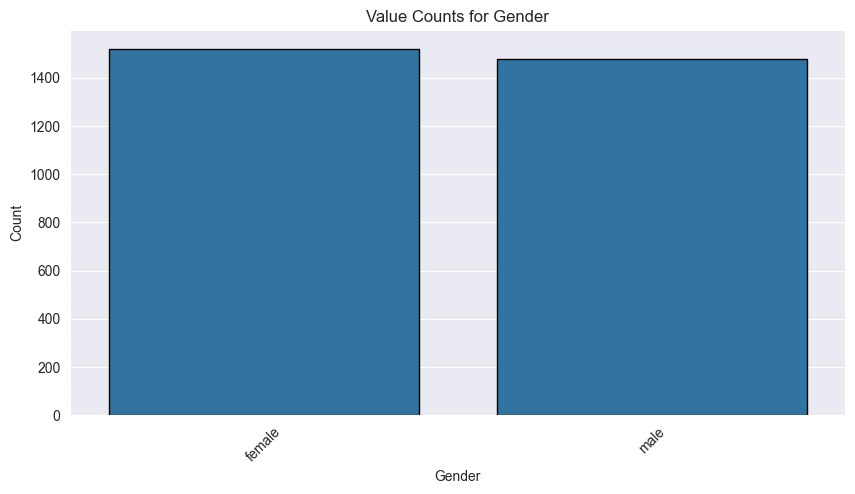

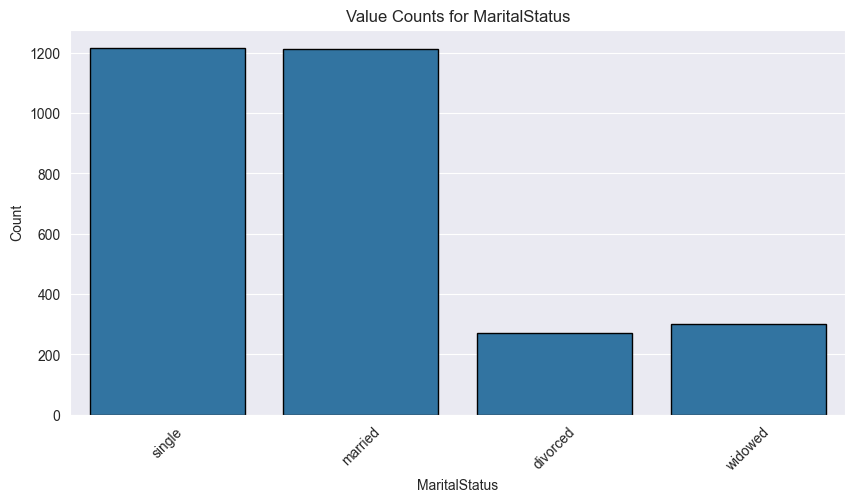

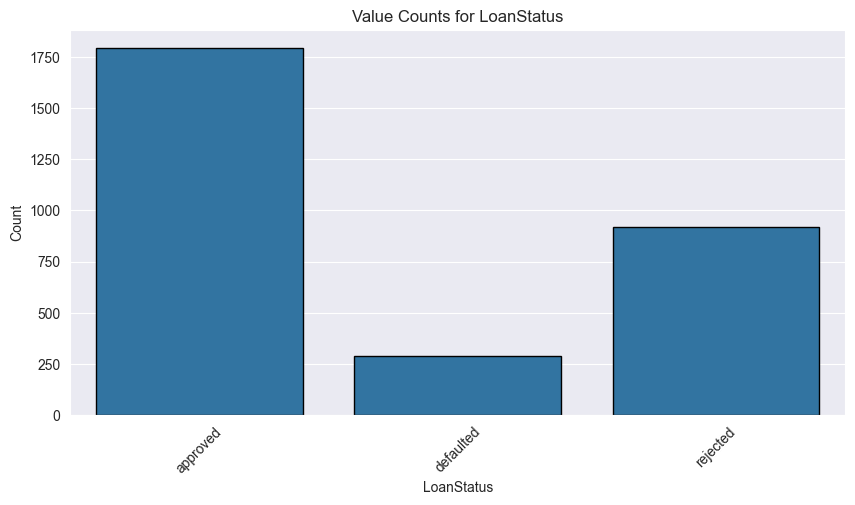

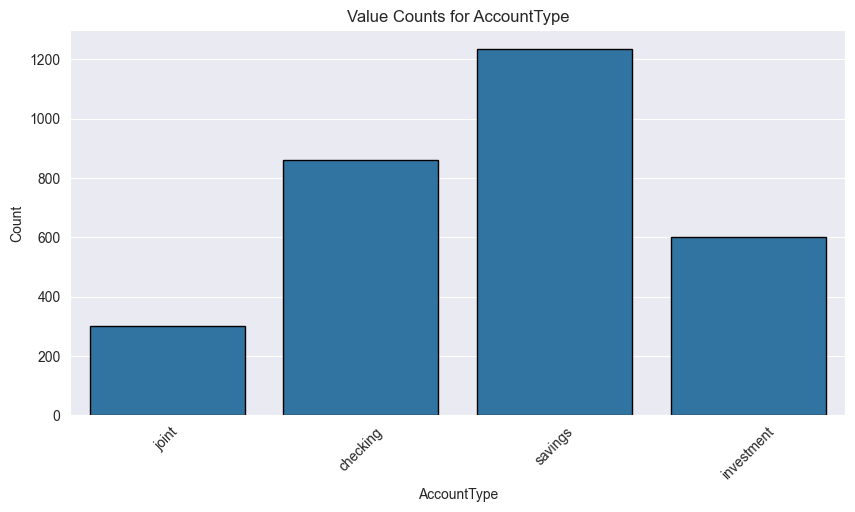

In [339]:
# Part 2: Visualization for categorical columns
# Value Counts and categorical distribution (except our target variable 'Churn')
categorical_columns = df.select_dtypes(include='object').columns
categorical_columns = categorical_columns.drop('Churn')

for column in categorical_columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=column, edgecolor='black')
    plt.title(f"Value Counts for {column}")
    print("\n")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

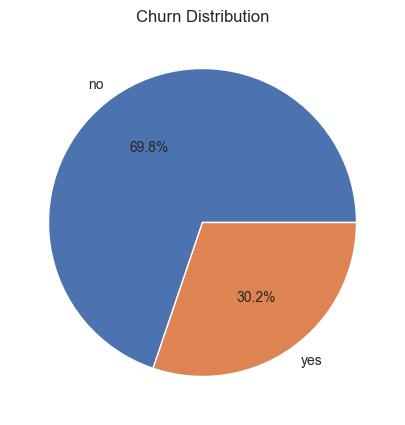

In [340]:
# Pie Chart for our target variable 'Churn'
churn_counts = df['Churn'].value_counts()

data = churn_counts.values
labels = churn_counts.index

colors = sns.color_palette('deep')
plt.figure(figsize=(10, 5))
plt.pie(data, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title("Churn Distribution")
plt.show()

### Insights from the Categorical Distributions
Gender
- After cleaning the Gender column inconsistencies, the distribution of customers is **almost evenly balanced** between male and female
- There is **no meaningful gender imbalance** in the dataset, meaning unbiased categorical analysis.

MaritalStatus
- The distribution of customers is **almost evenly split between Single and Married** customers, together representing the majority of our sample.
- Divorced and widowed customers are significantly smaller in numbers than the rest of the population, as normally expected from the young-to-middle-aged population of our dataset (25–55 years old).
- Multiclass variable with two main classes: single and married and two minorities: divorced and widowed.
- The balance between the two main classes means unbiased categorical analysis.

LoanStatus
- LoanStatus is **heavily imbalanced**.
- Approved loans are the most dominant class, followed by a significant number of rejected loans, followed by the minority class of defaulted loans.
- The number of defaulted loans is very low, meaning the underrepresentation of this category misses useful insights.
- Imbalance in LoanStatus is a **critical finding**.

AccountType
- The distribution of the account types is **uneven**; savings accounts are the most common type, followed by checking accounts.
- Joint accounts are the least common, although the married customers are much more, meaning most customers **prefer to have an individual account**.
- All classes are **satisfactorily represented**, providing useful insights for the analysis.

Churn
- The pie chart shows that 30.2% of the customers left the bank, while 69.8% of them stayed.
- The imbalance is **not significantly extreme**, but it is still worth noting.

# 7. Univariate Analysis
In this step we are going to examine each feature’s distribution, skewness, and modality using histograms and barplots.

In [341]:
# Part 1: Numerical variables and skewness
numerical_columns = df.select_dtypes(include=['float64']).columns

df[numerical_columns].skew()

Age              0.053028
Income           0.067716
Savings          2.970104
CreditScore      0.060470
LoanAmount       0.052558
YearsWithBank    2.501458
dtype: float64

### Insights for skewness of the data
| Feature       | Skewness | Distribution Characteristics          |
|---------------|----------|---------------------------------------|
| Age           | 0.053    | Almost perfectly symmetric            |
| Income        | 0.068    | Almost perfectly symmetric            |
| Savings       | 2.970    | Strongly right-skewed, heavy outliers |
| CreditScore   | 0.060    | Almost perfectly symmetric            |
| LoanAmount    | 0.053    | Almost perfectly symmetric            |
| YearsWithBank | 2.501    | Strongly right-skewed, clear outliers |

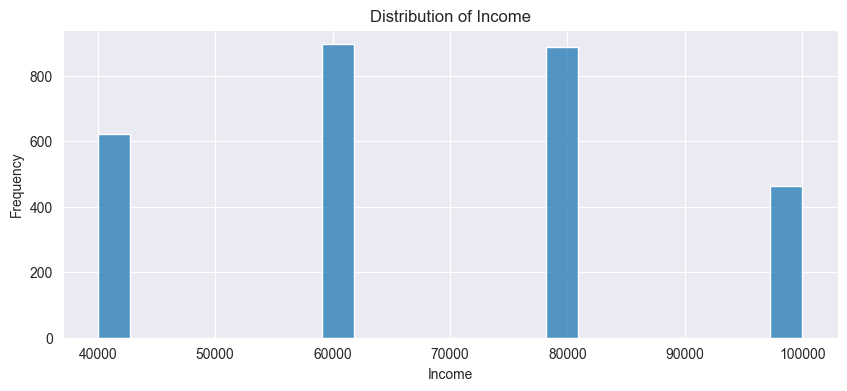

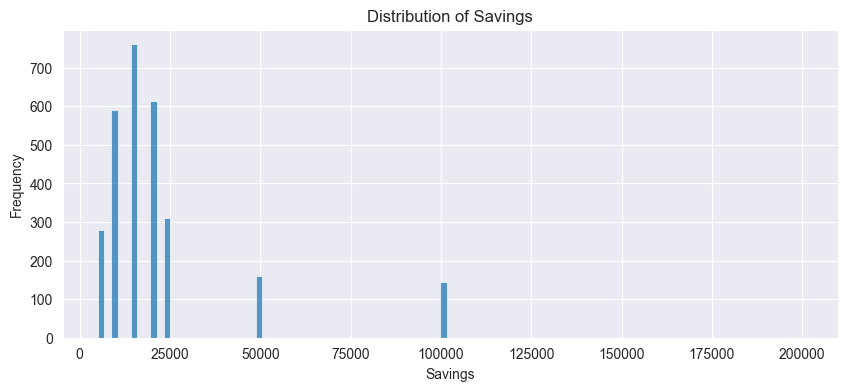

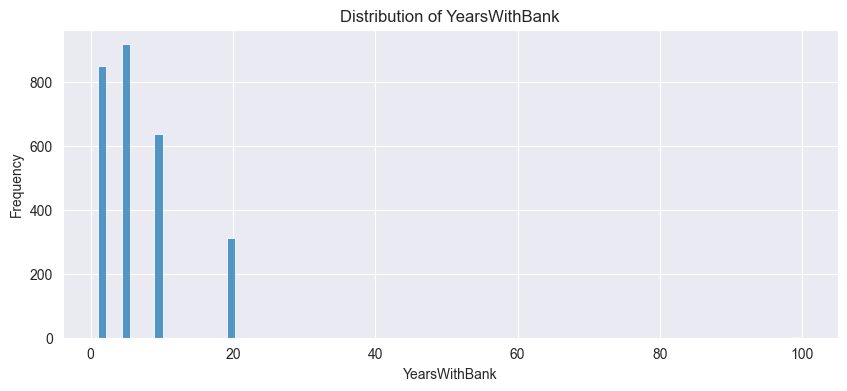

In [342]:
# Part 2: Visualization for skewed numerical columns with histograms
skewed_columns = ['Income','Savings','YearsWithBank']

for column in skewed_columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[column])
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()


### Insights for the histograms
- The distribution of Income is slightly skewed to the right with most customers earning between 60,000 to 80,000, extreme values are limited; there is no sign of outliers.
- The distribution of Savings is strongly skewed to the right with most customers having between 5,000 to 25,000; there are several extreme values, which confirm the existence of outliers.
- The distribution of YearsWithBank is strongly skewed to the right with most customers having a bank account for 5 to 10 years; a small group shows 20 years of banking history, which can be realistic for long-term clients.
- The one extreme value at 100 years is not even visible in the far right of the histogram, indicating a probable data entry error.

# 8. Outlier Detection
In this step we identify potential outliers using box plots, scatter plots, etc. This helps assess data quality and whether special treatment is needed.

In [343]:
# Checking the YearsWithBank column for extreme values, because of the unrealistic value of 100 years
df['YearsWithBank'][df['YearsWithBank'] > 10]

10      20.0
35      20.0
57      20.0
64      20.0
72      20.0
        ... 
2974    20.0
2978    20.0
2981    20.0
2986    20.0
2989    20.0
Name: YearsWithBank, Length: 311, dtype: float64

### Insights for YearWithBank
- A few customers have a bank account in the bank for 20 years, which can be realistic for long-term clients.
- There is a single extreme value of 100 years, which is unrealistic; it is likely a data entry error and should be handled.
- This is confirmed by the strong right-skew and the clear presence of an outlier.

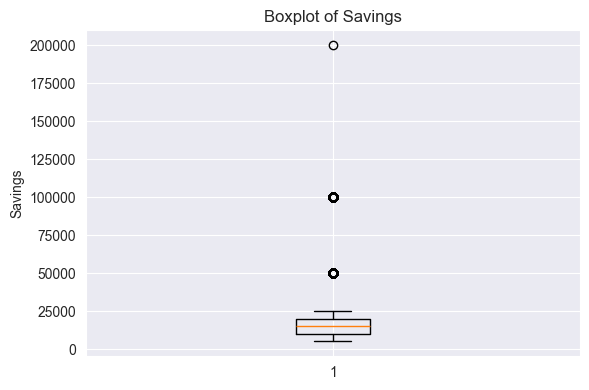

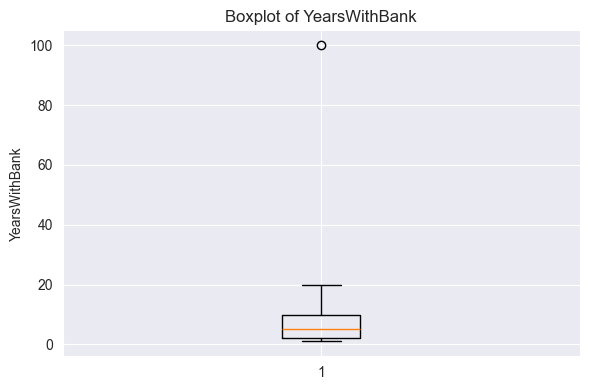

In [344]:
# Part 3: Visualization for numerical features with outliers using box plots
outlier_columns = ['Savings', 'YearsWithBank']

for column in outlier_columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[column].dropna(), showfliers=True)
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

### Insights for the box plots
 - The boxplot of Savings shows several extreme outliers around 50,000, 100,000 and 200,000. This confirms the significant number of outliers.
  - The boxplot of YearsWithBank shows one unrealistic extreme outlier at 100 years, likely due to a data entry error. Most customers remain between 1 and 10 years, with a realistically smaller group at 20 years. This confirms an individual major extreme outlier.

# 9. Bivariate & Multivariate Analysis
In this step we explore relationships between features using scatter plots or box plots.

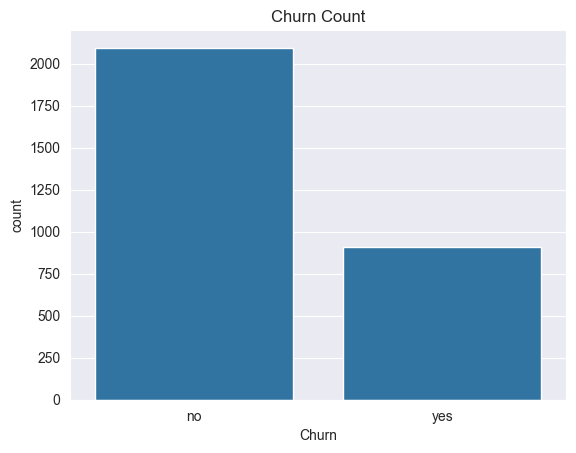

In [345]:
# Part 1: Categorical vs. Churn (Count plots)
# A. Categorical vs. Churn
sns.countplot(x='Churn', data=df)
plt.title("Churn Count")
plt.show()

Insight Count plot A
- Data is slightly imbalanced.

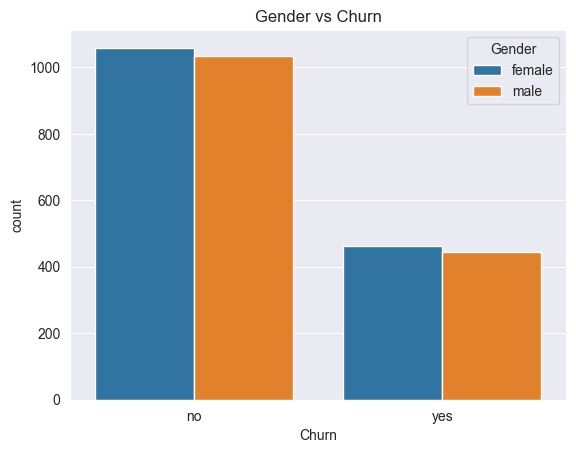

In [346]:
# B. Gender vs. Churn
sns.countplot(x='Churn', hue='Gender', data=df)
plt.title("Gender vs Churn")
plt.show()

Insight Count plot B
- Churn rates are very close for both female and male customers.
- This shows that Gender does not influence the Churn rate.
- This indicates that Gender is not a strong predictor for our model.

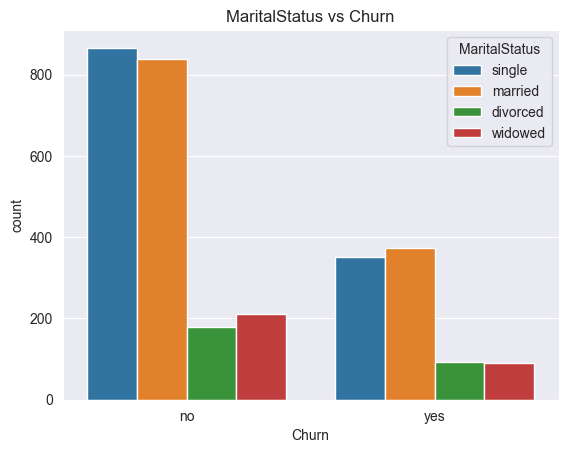

In [347]:
# C. MaritalStatus vs. Churn
sns.countplot(x='Churn', hue='MaritalStatus', data=df)
plt.title("MaritalStatus vs Churn")
plt.show()

Insight Count plot C
- Single and married customers show similar churn rates, meaning these two categories do not influence Churn rate.
- Divorced and widowed customers also show similar churn behavior, although the sample is much smaller.
- This indicates that MaritalStatus is not an important predictor for our model.

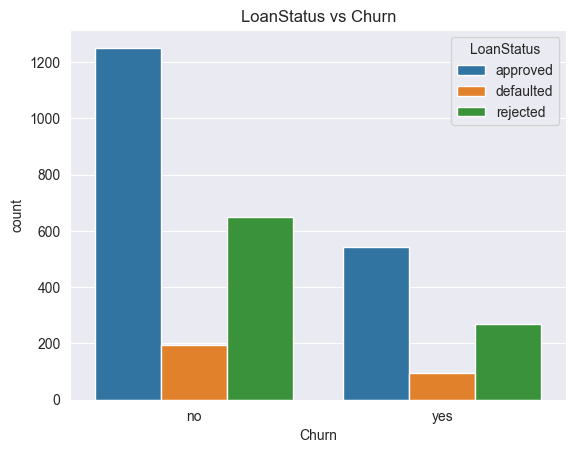

In [348]:
# D. LoanStatus vs. Churn
sns.countplot(x='Churn', hue='LoanStatus', data=df)
plt.title("LoanStatus vs Churn")
plt.show()

Insight Count plot D
- Approved and rejected customers show similar churn behavior.
- Defaulted customers show a slightly higher churn rate, which seems logical due to the loan issues.
- Despite these small variations in loan categories, LoanStatus seems to be a weak predictor of churn.

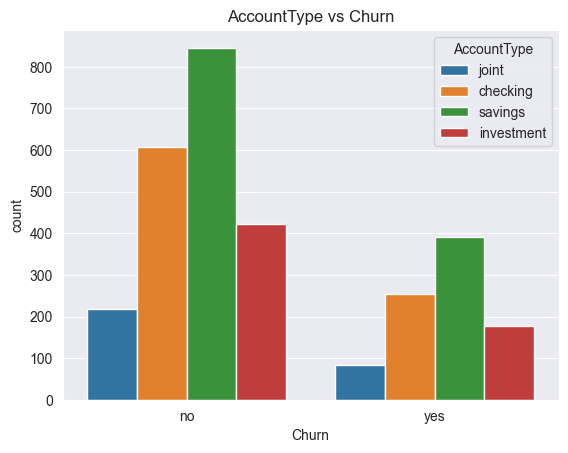

In [349]:
# E. AccountType vs. Churn
sns.countplot(x='Churn', hue='AccountType', data=df)
plt.title("AccountType vs Churn")
plt.show()

Insight Count plot E
- All account types show similar churn rates, meaning AccountType does not influence Churn rate greatly.
- Although the savings account is the most common type, all the account types show similar churn behavior.
- This indicates that AccountType is not an important predictor for our model.

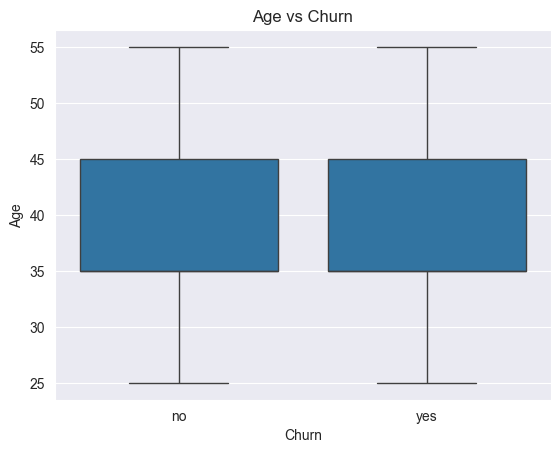

In [350]:
# Part 2: Numerical vs. Churn (Box plots)
# A. Age vs. Churn
sns.boxplot(x='Churn', y='Age', data=df)
plt.title("Age vs Churn")
plt.show()

Insight Box Plot A
- Age distribution seems to be the same for churned and non-churned customers.
- This indicates that Age is not a strong predictor for our model.

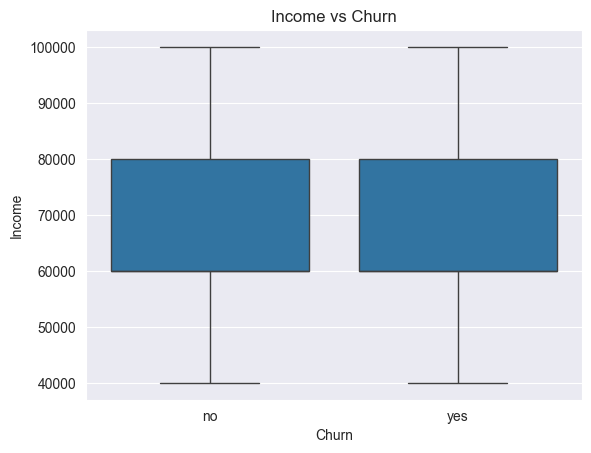

In [351]:
# B. Income vs. Churn
sns.boxplot(x='Churn', y='Income', data=df)
plt.title("Income vs Churn")
plt.show()

Insight Box Plot B
- Income distribution seems to be the same for both churned and non-churned customers.
- This indicates that Income is not a strong predictor for our model.

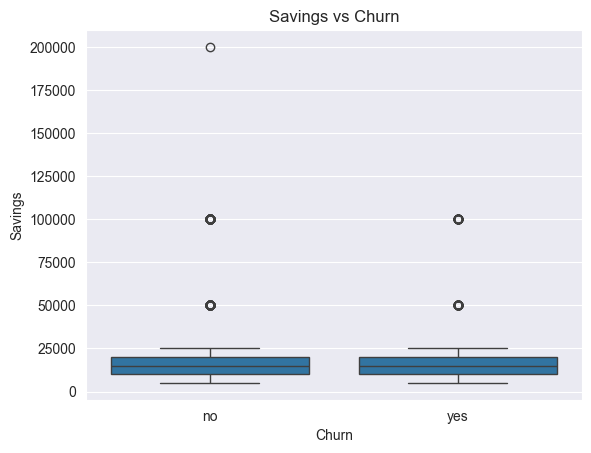

In [352]:
# C. Savings vs. Churn
sns.boxplot(x='Churn', y='Savings', data=df)
plt.title("Savings vs Churn")
plt.show()

Insight Box Plot C
- Savings distribution seems to be the same for both churned and non-churned customers.
- We can see some outliers in both categories.
- This indicates that Savings is not a strong predictor for our model.

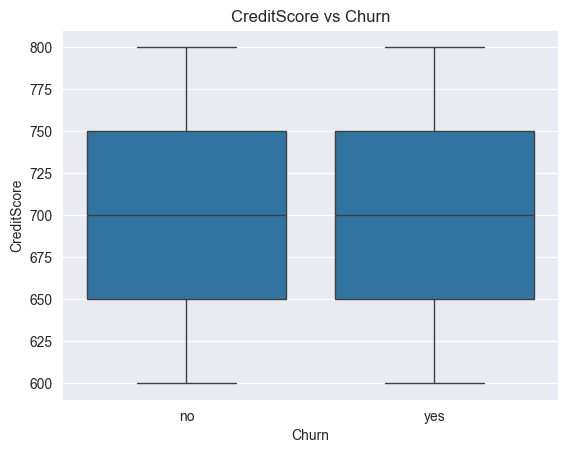

In [353]:
# D. CreditScore vs. Churn
sns.boxplot(x='Churn', y='CreditScore', data=df)
plt.title("CreditScore vs Churn")
plt.show()

Insight Box Plot D
- CreditScore distribution seems to be the same for both churned and non-churned customers.
- This indicates that CreditScore is not a strong predictor for our model.

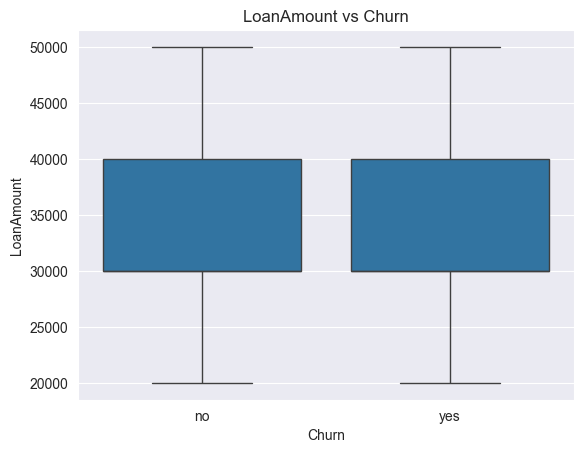

In [354]:
# E. LoanAmount vs. Churn
sns.boxplot(x='Churn', y='LoanAmount', data=df)
plt.title("LoanAmount vs Churn")
plt.show()

Insight Box Plot E
- LoanAmount distribution seems to be the same for both churned and non-churned customers.
- This indicates that LoanAmount is not a strong predictor for our model.

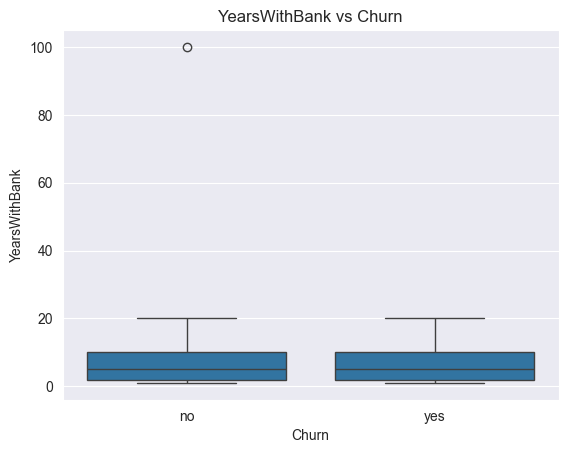

In [355]:
# F. YearsWithBank vs. Churn
sns.boxplot(x='Churn', y='YearsWithBank', data=df)
plt.title("YearsWithBank vs Churn")
plt.show()

Insight Box Plot F
- YearsWithBank distribution seems to be the same for both churned and non-churned customers.
- This indicates that YearsWithBank is not a strong predictor for our model.

# 10. Correlation Analysis
In this step we are going to analyze feature correlation using statistical methods such as Pearson correlation, Variance Threshold, Information Gain, and check the correlation between features and the target variable (Churn).

                    Age    Income   Savings  CreditScore  LoanAmount  \
Age            1.000000  0.004906 -0.018344    -0.027229    0.014082   
Income         0.004906  1.000000 -0.018970     0.021556    0.034780   
Savings       -0.018344 -0.018970  1.000000    -0.005522   -0.021526   
CreditScore   -0.027229  0.021556 -0.005522     1.000000   -0.022302   
LoanAmount     0.014082  0.034780 -0.021526    -0.022302    1.000000   
YearsWithBank  0.020964  0.021566  0.034405    -0.024266   -0.035155   

               YearsWithBank  
Age                 0.020964  
Income              0.021566  
Savings             0.034405  
CreditScore        -0.024266  
LoanAmount         -0.035155  
YearsWithBank       1.000000  


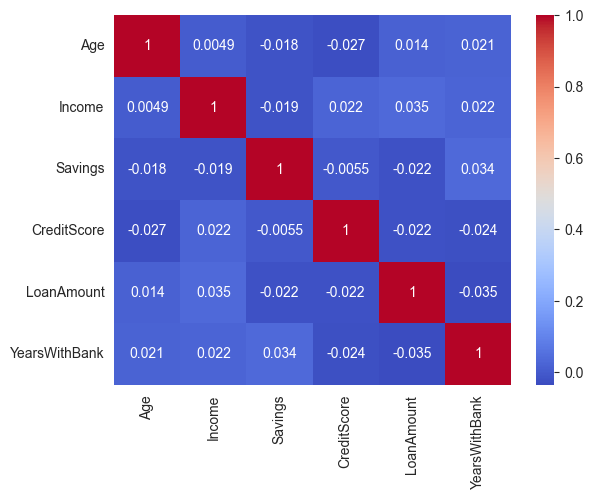

In [356]:
# Part 1: Correlation Matrix
# Compute correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Print correlation matrix
print(correlation_matrix)

# Plot correlation heatmap
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=True)

# Display heatmap
plt.show()

### Insights from correlation matrix
- **Extremely Weak Linear Relationships:** All correlation coefficients range between -0.035 (`YearsWithBank` vs `LoanAmount`) and +0.035 (`LoanAmount` vs `Income`). This mathematically proves that there are no meaningful linear dependencies among the numerical features in the dataset; this means that there exist low correlations across all numerical features.
- **High Feature Independence:** No structural multicollinearity is detected. Every single continuous variable behaves independently of the others, which is highly beneficial for avoiding feature redundancy in later stages.
- **Limitations of Linear Correlation:** Since all Pearson correlation values are clustered tightly around 0, standard linear metrics cannot capture any non-linear patterns that might exist. This highlights the absolute necessity of leveraging non-linear feature selection techniques, such as Mutual Information, in the next steps to uncover non-linear interactions with our target variable (`Churn`).

In [357]:
# Part 2: Variance Threshold

# Select only numerical features
numerical_features = df_clean[['Age', 'Income', 'Savings', 'CreditScore', 'LoanAmount', 'YearsWithBank']]

# Apply Variance Threshold
threshold = 0.1
selector = VarianceThreshold(threshold=threshold)
selected_features = selector.fit_transform(numerical_features)

print("Features selected by Variance Threshold:", selector.get_support(indices=True))


Features selected by Variance Threshold: [0 1 2 3 4 5]


### Insights from Variance Threshold
- The Variance Threshold does not remove any features because all of them are above the threshold.
- All features are retained because of their sufficient variability.

In [358]:
# Part 3: Information Gain

# Encode Churn as numerical
df_clean['Churn_Encoded'] = df_clean['Churn'].map({'no': 0, 'yes': 1})

# Select numerical features and Target variable
X = df_clean[['Age', 'Income', 'Savings', 'CreditScore', 'LoanAmount', 'YearsWithBank']]
y = df_clean['Churn_Encoded']

# Calculate Information Gain
info_gain = mutual_info_classif(X, y, random_state=0)

print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("Mutual Information (Information Gain) Scores:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
for index, gain in enumerate(info_gain):
    print(f"Information Gain for feature '{X.columns[index]}' is: {gain:.4f}")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Mutual Information (Information Gain) Scores:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Information Gain for feature 'Age' is: 0.0000
Information Gain for feature 'Income' is: 0.0000
Information Gain for feature 'Savings' is: 0.0000
Information Gain for feature 'CreditScore' is: 0.0037
Information Gain for feature 'LoanAmount' is: 0.0103
Information Gain for feature 'YearsWithBank' is: 0.0004


### Insights from Information Gain
- Τhe majority of the continuous features (such as `Age`, `Income`, and `Savings`) display a Mutual Information score of exactly 0.0000, proving they share no measurable non-linear dependency with the target variable (`Churn`).
- **Top Predictive Features:** - **LoanAmount:** Yields the highest score of 0.0103, indicating it holds the strongest (albeit modest) predictive power regarding customer churn.
  - **CreditScore:** Follows with a score of 0.0037.
  - **YearsWithBank:** Shows a marginal score of 0.0004.
- This statistical baseline confirms that the continuous numerical features carry very limited predictive signal for customer churn. Combined with the bivariate analysis — where categorical features such as LoanStatus and AccountType also showed weak differentiation — the overall dataset appears to have low predictive power. A formal chi-square test on the categorical features would be needed to statistically confirm their relationship with Churn before drawing stronger conclusions.

# 11. Domain-Specific Feature Understanding



In the banking domain several features are considered to play an important role in the churn rate. For the bank environment, the factors that generally affect the churn rate would include Income, Savings, CreditScore, LoanAmount, LoanStatus, AccountType, and YearsWithBank. However, we have discovered in our dataset that these expected patterns do not apply, since during the analysis the majority of both the numerical and categorical features showed very weak relationships with churn.

# 12. Features Selection
In this step we are going to select the most important features for our model.

Generally speaking, after the analysis of the data, we can conclude that the dataset is weak for model training, but if we must apply the feature selection step, there are some features that have a slight advantage over others:

- From the bivariate analysis, LoanStatus is the only categorical variable that showed any differentiation in churn behavior, so we are going to keep it despite being a weak predictor of Churn.
- Correlation Analysis showed that all correlations are extremely low; no feature is highly correlated with the target variable.
- In Variance Threshold, no numerical features were removed because all passed the threshold.
- Information Gain showed weak predictive value across all numerical features; we retain LoanAmount and CreditScore as they yielded the highest scores (0.0103 and 0.0037 respectively).
- YearsWithBank (MI = 0.0004) and Age (MI = 0.0000) are both excluded, as neither demonstrates meaningful predictive signal and domain relevance alone is not enough to justify their inclusion given the overall weakness of the dataset. AccountType is also excluded, as the bivariate analysis confirmed no meaningful differentiation in churn behavior across account types.
- We are not going to keep CustomerID, Age, Gender, MaritalStatus, Income, Savings, YearsWithBank, or AccountType.
- The original textual Churn column is dropped to avoid redundancy, and Churn_Encoded is selected as our final target variable. This binary format (where "no" is mapped to 0 and "yes" to 1) is fully optimized for machine learning classification algorithms.

# 13. Prepare Final Dataset
The final step of our EDA is to create a clean, processed dataset with selected features.

In [359]:
# Create the final dataset with selected features
selected_columns = ['LoanAmount', 'CreditScore', 'LoanStatus', 'Churn_Encoded']

final_df = df_clean[selected_columns]

# Save the final cleaned dataset as a new CSV file
final_df.to_csv("final_cleaned_dataset.csv", index=False)

print("Final cleaned dataset saved successfully.")


Final cleaned dataset saved successfully.
